# 07. Final Comparison and Error Analysis

Notebook này ghi lại kết quả của **Stage 7 — Final Comparison + Error Analysis**.

Vai trò của notebook:

- Không train lại model.
- Không sinh lại noisy data.
- Không chạy lại toàn bộ pipeline nếu output đã có.
- Chỉ đọc các bảng/hình đã sinh ra từ `scripts/run_final_comparison.py`.
- Tổng hợp kết quả cuối cùng giữa baseline và PhoBERT.
- Phân tích lỗi định lượng và định tính để chuẩn bị viết báo cáo.

Các câu hỏi nghiên cứu được trả lời trong notebook này:

```text
RQ1: PhoBERT có vượt baseline trên clean test không?
RQ2: Loại noise nào gây suy giảm mạnh nhất?
RQ3: PhoBERT có bền hơn baseline trên noisy text không?
RQ4: Các lỗi chính xuất hiện ở lớp nào và theo hướng nhầm nào?
```

## 1. Setup

In [2]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image

cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd

print("Project root:", ROOT)

TABLES_DIR = ROOT / "outputs" / "tables"
FIGURES_DIR = ROOT / "outputs" / "figures"
REPORTS_DIR = ROOT / "outputs" / "reports"
METRICS_DIR = ROOT / "outputs" / "metrics"
PREDICTIONS_DIR = ROOT / "outputs" / "predictions"

Project root: d:\project-ml-engineering\viedufeedback-robust


## 2. Kiểm tra output Stage 7 bắt buộc

Các file này phải tồn tại sau khi chạy:

```powershell
python scripts/run_final_comparison.py
```

In [3]:
required_files = {
    "final_model_comparison": TABLES_DIR / "final_model_comparison.csv",
    "final_robustness_comparison": TABLES_DIR / "final_robustness_comparison.csv",
    "final_per_class_comparison": TABLES_DIR / "final_per_class_comparison.csv",
    "error_examples_sentiment": TABLES_DIR / "error_examples_sentiment.csv",
    "error_examples_topic": TABLES_DIR / "error_examples_topic.csv",
    "error_transition_summary_sentiment": TABLES_DIR / "error_transition_summary_sentiment.csv",
    "error_transition_summary_topic": TABLES_DIR / "error_transition_summary_topic.csv",
    "final_clean_macro_f1_figure": FIGURES_DIR / "final_clean_macro_f1_comparison.png",
    "final_robustness_macro_f1_sentiment": FIGURES_DIR / "final_robustness_macro_f1_sentiment.png",
    "final_robustness_macro_f1_topic": FIGURES_DIR / "final_robustness_macro_f1_topic.png",
    "final_robustness_drop_sentiment": FIGURES_DIR / "final_robustness_drop_sentiment.png",
    "final_robustness_drop_topic": FIGURES_DIR / "final_robustness_drop_topic.png",
    "final_report": REPORTS_DIR / "final_comparison_report.md",
    "final_metrics_json": METRICS_DIR / "final_comparison_metrics.json",
}

check_df = pd.DataFrame(
    [{"name": name, "path": str(path), "exists": path.exists()} for name, path in required_files.items()]
)

display(check_df)

missing = check_df.loc[~check_df["exists"], "name"].tolist()
if missing:
    raise FileNotFoundError(f"Missing Stage 7 files: {missing}")

print("All required Stage 7 files exist.")

,name,path,exists
0,final_model_comparison,d:\project-ml-engineering\viedufeedback-robust...,True
1,final_robustness_comparison,d:\project-ml-engineering\viedufeedback-robust...,True
2,final_per_class_comparison,d:\project-ml-engineering\viedufeedback-robust...,True
3,error_examples_sentiment,d:\project-ml-engineering\viedufeedback-robust...,True
4,error_examples_topic,d:\project-ml-engineering\viedufeedback-robust...,True
5,error_transition_summary_sentiment,d:\project-ml-engineering\viedufeedback-robust...,True
6,error_transition_summary_topic,d:\project-ml-engineering\viedufeedback-robust...,True
7,final_clean_macro_f1_figure,d:\project-ml-engineering\viedufeedback-robust...,True
8,final_robustness_macro_f1_sentiment,d:\project-ml-engineering\viedufeedback-robust...,True
9,final_robustness_macro_f1_topic,d:\project-ml-engineering\viedufeedback-robust...,True


All required Stage 7 files exist.


## 3. Load dữ liệu tổng hợp

In [4]:
final_model_comparison = pd.read_csv(TABLES_DIR / "final_model_comparison.csv")
final_robustness_comparison = pd.read_csv(TABLES_DIR / "final_robustness_comparison.csv")
final_per_class_comparison = pd.read_csv(TABLES_DIR / "final_per_class_comparison.csv")
error_examples_sentiment = pd.read_csv(TABLES_DIR / "error_examples_sentiment.csv")
error_examples_topic = pd.read_csv(TABLES_DIR / "error_examples_topic.csv")
transition_sentiment = pd.read_csv(TABLES_DIR / "error_transition_summary_sentiment.csv")
transition_topic = pd.read_csv(TABLES_DIR / "error_transition_summary_topic.csv")

display(Markdown("### final_model_comparison"))
display(final_model_comparison)

display(Markdown("### final_robustness_comparison preview"))
display(final_robustness_comparison.head(20))

display(Markdown("### final_per_class_comparison preview"))
display(final_per_class_comparison.head(20))

### final_model_comparison

,task,model,model_family,variant,accuracy,macro_f1,weighted_f1,rank_macro_f1,rank_accuracy,is_best_clean_macro_f1
0,sentiment,phobert,phobert,clean,0.931459,0.822815,0.929772,1,1,True
1,sentiment,tfidf_char_svm,baseline,clean,0.875237,0.738784,0.876528,2,3,False
2,sentiment,tfidf_word_svm,baseline,clean,0.891977,0.728904,0.887000,3,2,False
3,sentiment,majority,baseline,clean,0.502211,0.222876,0.335793,4,4,False
4,topic,phobert,phobert,clean,0.896399,0.800073,0.894241,1,1,True
5,topic,tfidf_word_svm,baseline,clean,0.858497,0.750922,0.859847,2,2,False
6,topic,tfidf_char_svm,baseline,clean,0.833544,0.732207,0.840575,3,3,False
7,topic,majority,baseline,clean,0.723310,0.209861,0.607178,4,4,False


### final_robustness_comparison preview

,task,model,model_family,variant,noise_type,noise_level,num_samples,accuracy,macro_f1,weighted_f1,...,macro_f1_drop,macro_f1_relative_drop_percent,clean_weighted_f1,variant_weighted_f1,weighted_f1_drop,weighted_f1_relative_drop_percent,rank_macro_f1_within_variant,is_best_model_for_variant,variant_order,model_order
0,sentiment,phobert,phobert,clean,clean,none,3166,0.931459,0.822815,0.929772,...,0.000000,0.0000,0.929772,0.929772,0.000000,0.0000,1,True,0,3
1,sentiment,tfidf_char_svm,baseline,clean,clean,none,3166,0.875237,0.738784,0.876528,...,0.000000,0.0000,0.876528,0.876528,0.000000,0.0000,2,False,0,2
2,sentiment,tfidf_word_svm,baseline,clean,clean,none,3166,0.891977,0.728904,0.887000,...,0.000000,0.0000,0.887000,0.887000,0.000000,0.0000,3,False,0,1
3,sentiment,majority,baseline,clean,clean,none,3166,0.502211,0.222876,0.335793,...,0.000000,0.0000,0.335793,0.335793,0.000000,0.0000,4,False,0,0
4,sentiment,phobert,phobert,typo_light,typo,light,3166,0.929248,0.820352,0.927437,...,0.002463,0.2993,0.929772,0.927437,0.002335,0.2511,1,True,1,3
5,sentiment,tfidf_char_svm,baseline,typo_light,typo,light,3166,0.873342,0.731545,0.874915,...,0.007240,0.9799,0.876528,0.874915,0.001613,0.1840,2,False,1,2
6,sentiment,tfidf_word_svm,baseline,typo_light,typo,light,3166,0.887871,0.722617,0.882547,...,0.006287,0.8626,0.887000,0.882547,0.004453,0.5020,3,False,1,1
7,sentiment,majority,baseline,typo_light,typo,light,3166,0.502211,0.222876,0.335793,...,0.000000,0.0000,0.335793,0.335793,0.000000,0.0000,4,False,1,0
8,sentiment,phobert,phobert,typo_medium,typo,medium,3166,0.927353,0.818815,0.926026,...,0.004000,0.4861,0.929772,0.926026,0.003746,0.4029,1,True,2,3
9,sentiment,tfidf_char_svm,baseline,typo_medium,typo,medium,3166,0.870499,0.731212,0.872558,...,0.007572,1.0250,0.876528,0.872558,0.003969,0.4529,2,False,2,2


### final_per_class_comparison preview

,task,model,variant,label,precision,recall,f1_score,support,model_family,is_summary_label,variant_order,model_order
0,sentiment,majority,clean,negative,0.000000,0.000000,0.000000,1409.0,baseline,False,0,0
1,sentiment,majority,clean,neutral,0.000000,0.000000,0.000000,167.0,baseline,False,0,0
2,sentiment,majority,clean,positive,0.502211,1.000000,0.668629,1590.0,baseline,False,0,0
3,sentiment,majority,clean,accuracy,NaN,NaN,0.502211,NaN,baseline,True,0,0
4,sentiment,majority,clean,macro avg,0.167404,0.333333,0.222876,3166.0,baseline,True,0,0
5,sentiment,majority,clean,weighted avg,0.252216,0.502211,0.335793,3166.0,baseline,True,0,0
6,sentiment,tfidf_word_svm,clean,negative,0.882119,0.945351,0.912641,1409.0,baseline,False,0,1
7,sentiment,tfidf_word_svm,clean,neutral,0.445455,0.293413,0.353791,167.0,baseline,False,0,1
8,sentiment,tfidf_word_svm,clean,positive,0.933376,0.907547,0.920281,1590.0,baseline,False,0,1
9,sentiment,tfidf_word_svm,clean,accuracy,NaN,NaN,0.891977,NaN,baseline,True,0,1


## 4. Clean test comparison

Mục tiêu: trả lời RQ1 — PhoBERT có vượt baseline trên dữ liệu sạch không?

In [5]:
clean_comparison = final_model_comparison.copy()
clean_comparison = clean_comparison.sort_values(["task", "rank_macro_f1"])

display(clean_comparison)

best_clean = clean_comparison[clean_comparison["is_best_clean_macro_f1"] == True].copy()
display(Markdown("### Best model on clean test by task"))
display(best_clean[["task", "model", "accuracy", "macro_f1", "weighted_f1"]])

for _, row in best_clean.iterrows():
    display(Markdown(
        f"- **{row['task']}**: best clean model is **{row['model']}** "
        f"with Macro-F1 = **{row['macro_f1']:.4f}** and Accuracy = **{row['accuracy']:.4f}**."
    ))

,task,model,model_family,variant,accuracy,macro_f1,weighted_f1,rank_macro_f1,rank_accuracy,is_best_clean_macro_f1
0,sentiment,phobert,phobert,clean,0.931459,0.822815,0.929772,1,1,True
1,sentiment,tfidf_char_svm,baseline,clean,0.875237,0.738784,0.876528,2,3,False
2,sentiment,tfidf_word_svm,baseline,clean,0.891977,0.728904,0.887000,3,2,False
3,sentiment,majority,baseline,clean,0.502211,0.222876,0.335793,4,4,False
4,topic,phobert,phobert,clean,0.896399,0.800073,0.894241,1,1,True
5,topic,tfidf_word_svm,baseline,clean,0.858497,0.750922,0.859847,2,2,False
6,topic,tfidf_char_svm,baseline,clean,0.833544,0.732207,0.840575,3,3,False
7,topic,majority,baseline,clean,0.723310,0.209861,0.607178,4,4,False


### Best model on clean test by task

,task,model,accuracy,macro_f1,weighted_f1
0,sentiment,phobert,0.931459,0.822815,0.929772
4,topic,phobert,0.896399,0.800073,0.894241


- **sentiment**: best clean model is **phobert** with Macro-F1 = **0.8228** and Accuracy = **0.9315**.

- **topic**: best clean model is **phobert** with Macro-F1 = **0.8001** and Accuracy = **0.8964**.

### Clean Macro-F1 figure

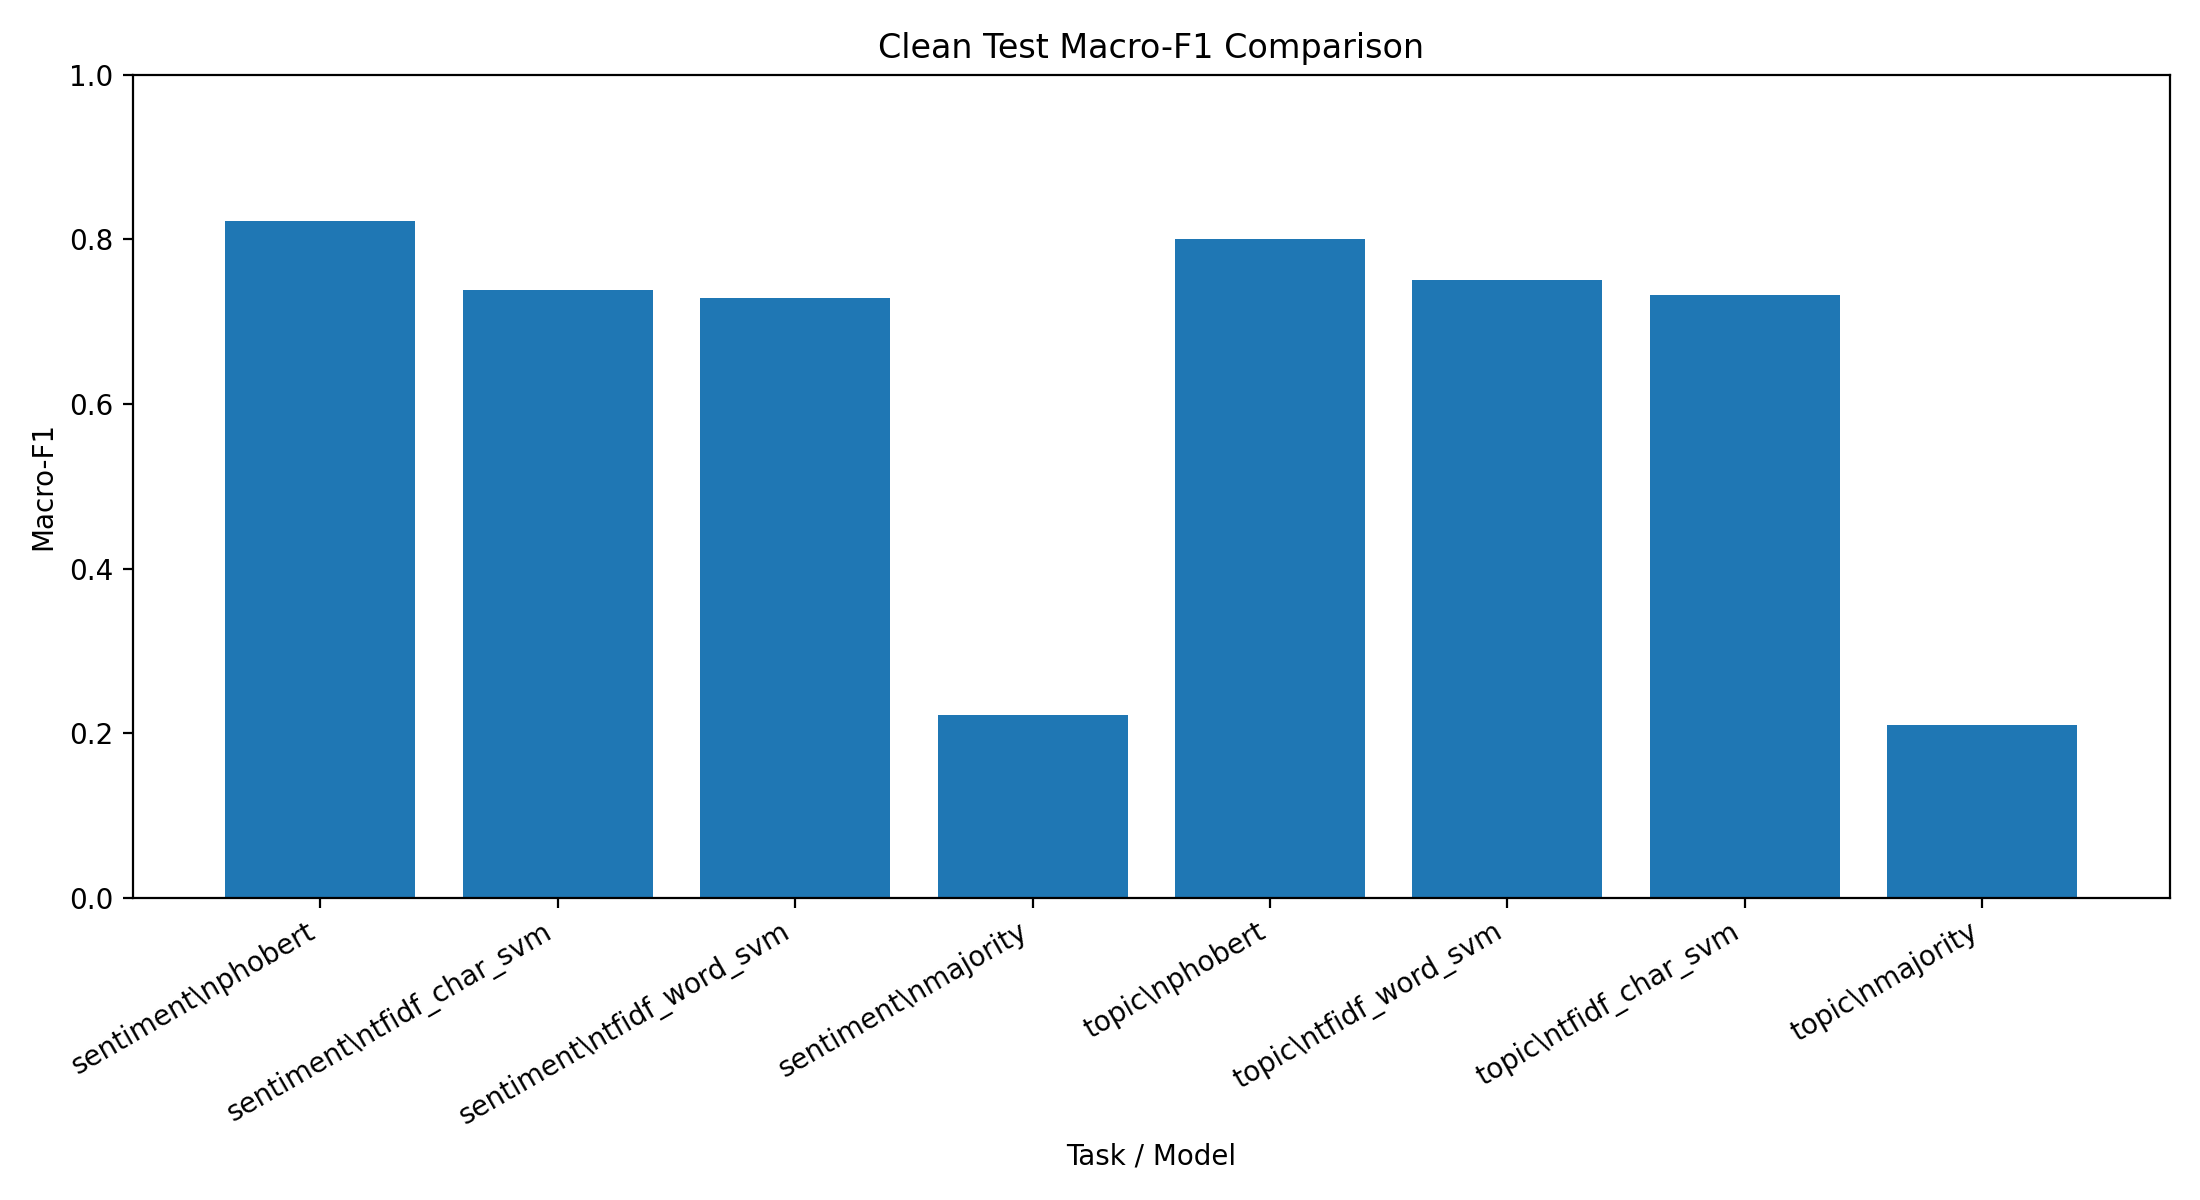

In [6]:
display(Image(filename=str(FIGURES_DIR / "final_clean_macro_f1_comparison.png")))

## 5. Robustness comparison by variant

Mục tiêu: so sánh toàn bộ model trên từng loại noise.

In [7]:
variant_order = [
    "clean",
    "typo_light",
    "typo_medium",
    "teencode_light",
    "mixed_light",
    "no_accent",
    "mixed_no_accent",
]

robustness = final_robustness_comparison.copy()
robustness["variant"] = pd.Categorical(
    robustness["variant"],
    categories=variant_order,
    ordered=True,
)
robustness = robustness.sort_values(["task", "variant", "rank_macro_f1_within_variant"])

display(robustness)

,task,model,model_family,variant,noise_type,noise_level,num_samples,accuracy,macro_f1,weighted_f1,...,macro_f1_drop,macro_f1_relative_drop_percent,clean_weighted_f1,variant_weighted_f1,weighted_f1_drop,weighted_f1_relative_drop_percent,rank_macro_f1_within_variant,is_best_model_for_variant,variant_order,model_order
0,sentiment,phobert,phobert,clean,clean,none,3166,0.931459,0.822815,0.929772,...,0.000000,0.0000,0.929772,0.929772,0.000000,0.0000,1,True,0,3
1,sentiment,tfidf_char_svm,baseline,clean,clean,none,3166,0.875237,0.738784,0.876528,...,0.000000,0.0000,0.876528,0.876528,0.000000,0.0000,2,False,0,2
2,sentiment,tfidf_word_svm,baseline,clean,clean,none,3166,0.891977,0.728904,0.887000,...,0.000000,0.0000,0.887000,0.887000,0.000000,0.0000,3,False,0,1
3,sentiment,majority,baseline,clean,clean,none,3166,0.502211,0.222876,0.335793,...,0.000000,0.0000,0.335793,0.335793,0.000000,0.0000,4,False,0,0
4,sentiment,phobert,phobert,typo_light,typo,light,3166,0.929248,0.820352,0.927437,...,0.002463,0.2993,0.929772,0.927437,0.002335,0.2511,1,True,1,3
5,sentiment,tfidf_char_svm,baseline,typo_light,typo,light,3166,0.873342,0.731545,0.874915,...,0.007240,0.9799,0.876528,0.874915,0.001613,0.1840,2,False,1,2
6,sentiment,tfidf_word_svm,baseline,typo_light,typo,light,3166,0.887871,0.722617,0.882547,...,0.006287,0.8626,0.887000,0.882547,0.004453,0.5020,3,False,1,1
7,sentiment,majority,baseline,typo_light,typo,light,3166,0.502211,0.222876,0.335793,...,0.000000,0.0000,0.335793,0.335793,0.000000,0.0000,4,False,1,0
8,sentiment,phobert,phobert,typo_medium,typo,medium,3166,0.927353,0.818815,0.926026,...,0.004000,0.4861,0.929772,0.926026,0.003746,0.4029,1,True,2,3
9,sentiment,tfidf_char_svm,baseline,typo_medium,typo,medium,3166,0.870499,0.731212,0.872558,...,0.007572,1.0250,0.876528,0.872558,0.003969,0.4529,2,False,2,2


## 6. Best model theo từng task và variant

Mục tiêu: trả lời RQ3 — PhoBERT có bền hơn baseline không?

In [8]:
best_by_variant = robustness[robustness["is_best_model_for_variant"] == True].copy()
best_by_variant = best_by_variant.sort_values(["task", "variant"])

display(best_by_variant[[
    "task",
    "variant",
    "model",
    "model_family",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "macro_f1_drop",
    "macro_f1_relative_drop_percent",
]])

for task, task_df in best_by_variant.groupby("task"):
    display(Markdown(f"### Best model by variant — {task}"))
    display(task_df[["variant", "model", "macro_f1", "macro_f1_drop"]])

,task,variant,model,model_family,accuracy,macro_f1,weighted_f1,macro_f1_drop,macro_f1_relative_drop_percent
0,sentiment,clean,phobert,phobert,0.931459,0.822815,0.929772,0.000000,0.0000
4,sentiment,typo_light,phobert,phobert,0.929248,0.820352,0.927437,0.002463,0.2993
8,sentiment,typo_medium,phobert,phobert,0.927353,0.818815,0.926026,0.004000,0.4861
12,sentiment,teencode_light,phobert,phobert,0.924826,0.814152,0.923594,0.008663,1.0528
16,sentiment,mixed_light,phobert,phobert,0.921668,0.813839,0.920467,0.008976,1.0909
20,sentiment,no_accent,tfidf_char_svm,baseline,0.474416,0.414024,0.522812,0.324760,43.9587
24,sentiment,mixed_no_accent,tfidf_char_svm,baseline,0.469678,0.411000,0.519813,0.327784,44.3680
28,topic,clean,phobert,phobert,0.896399,0.800073,0.894241,0.000000,0.0000
32,topic,typo_light,phobert,phobert,0.893557,0.795476,0.891452,0.004597,0.5746
36,topic,typo_medium,phobert,phobert,0.885344,0.786590,0.884517,0.013483,1.6852


### Best model by variant — sentiment

,variant,model,macro_f1,macro_f1_drop
0,clean,phobert,0.822815,0.000000
4,typo_light,phobert,0.820352,0.002463
8,typo_medium,phobert,0.818815,0.004000
12,teencode_light,phobert,0.814152,0.008663
16,mixed_light,phobert,0.813839,0.008976
20,no_accent,tfidf_char_svm,0.414024,0.324760
24,mixed_no_accent,tfidf_char_svm,0.411000,0.327784


### Best model by variant — topic

,variant,model,macro_f1,macro_f1_drop
28,clean,phobert,0.800073,0.000000
32,typo_light,phobert,0.795476,0.004597
36,typo_medium,phobert,0.786590,0.013483
40,teencode_light,phobert,0.785276,0.014797
44,mixed_light,phobert,0.777107,0.022966
48,no_accent,tfidf_char_svm,0.295702,0.436505
52,mixed_no_accent,tfidf_char_svm,0.300282,0.431925


## 7. Macro-F1 theo variant

Mục tiêu: trực quan hóa mô hình nào giảm mạnh khi gặp noise.

### Sentiment

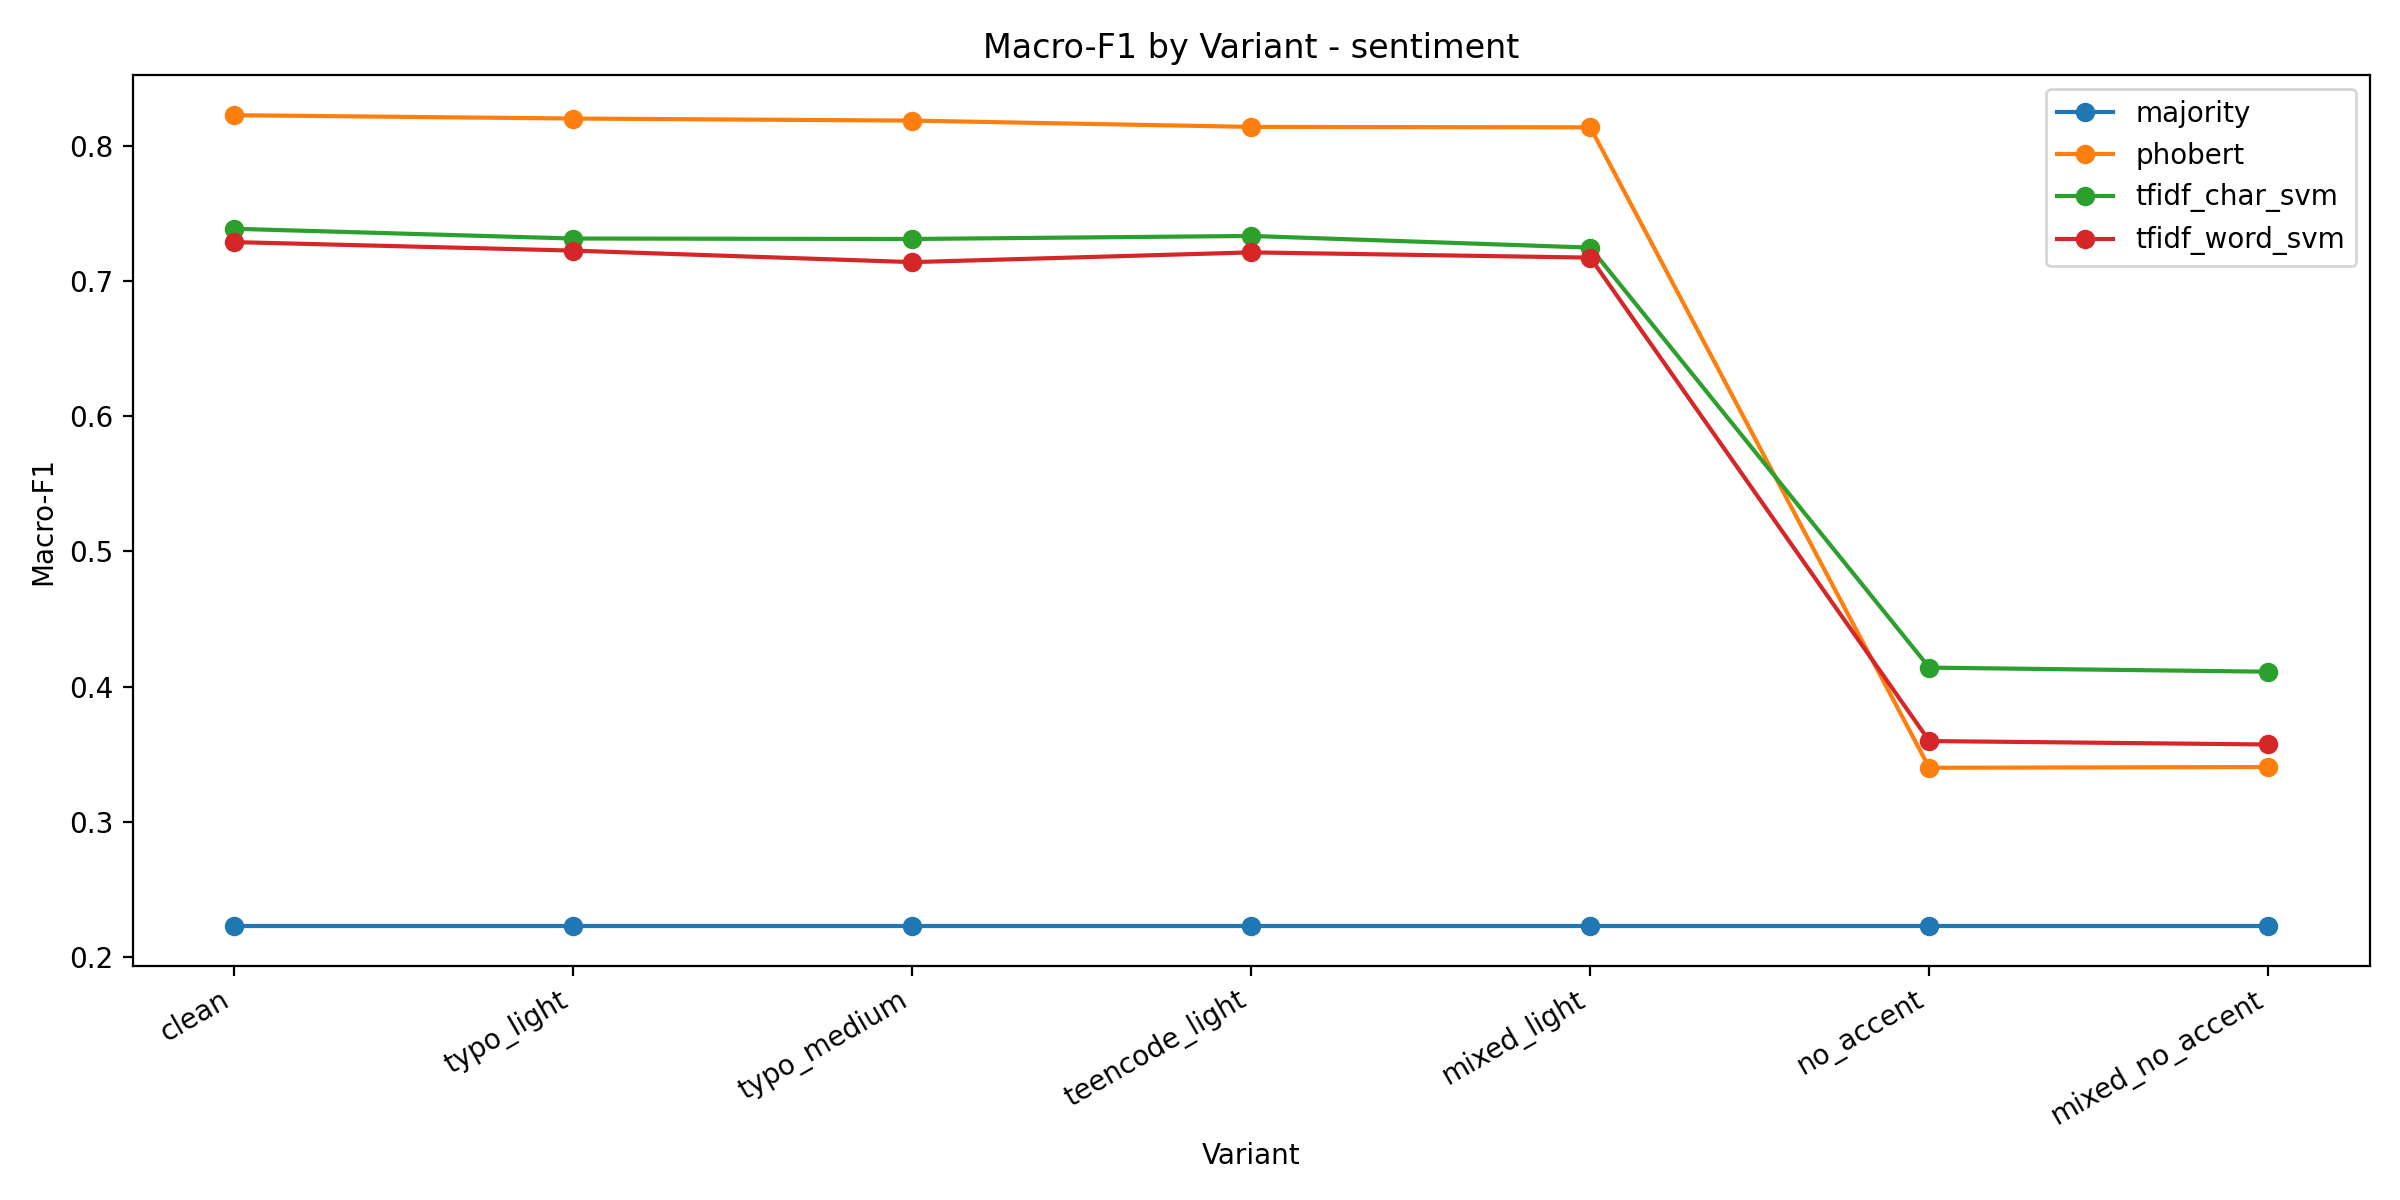

### Topic

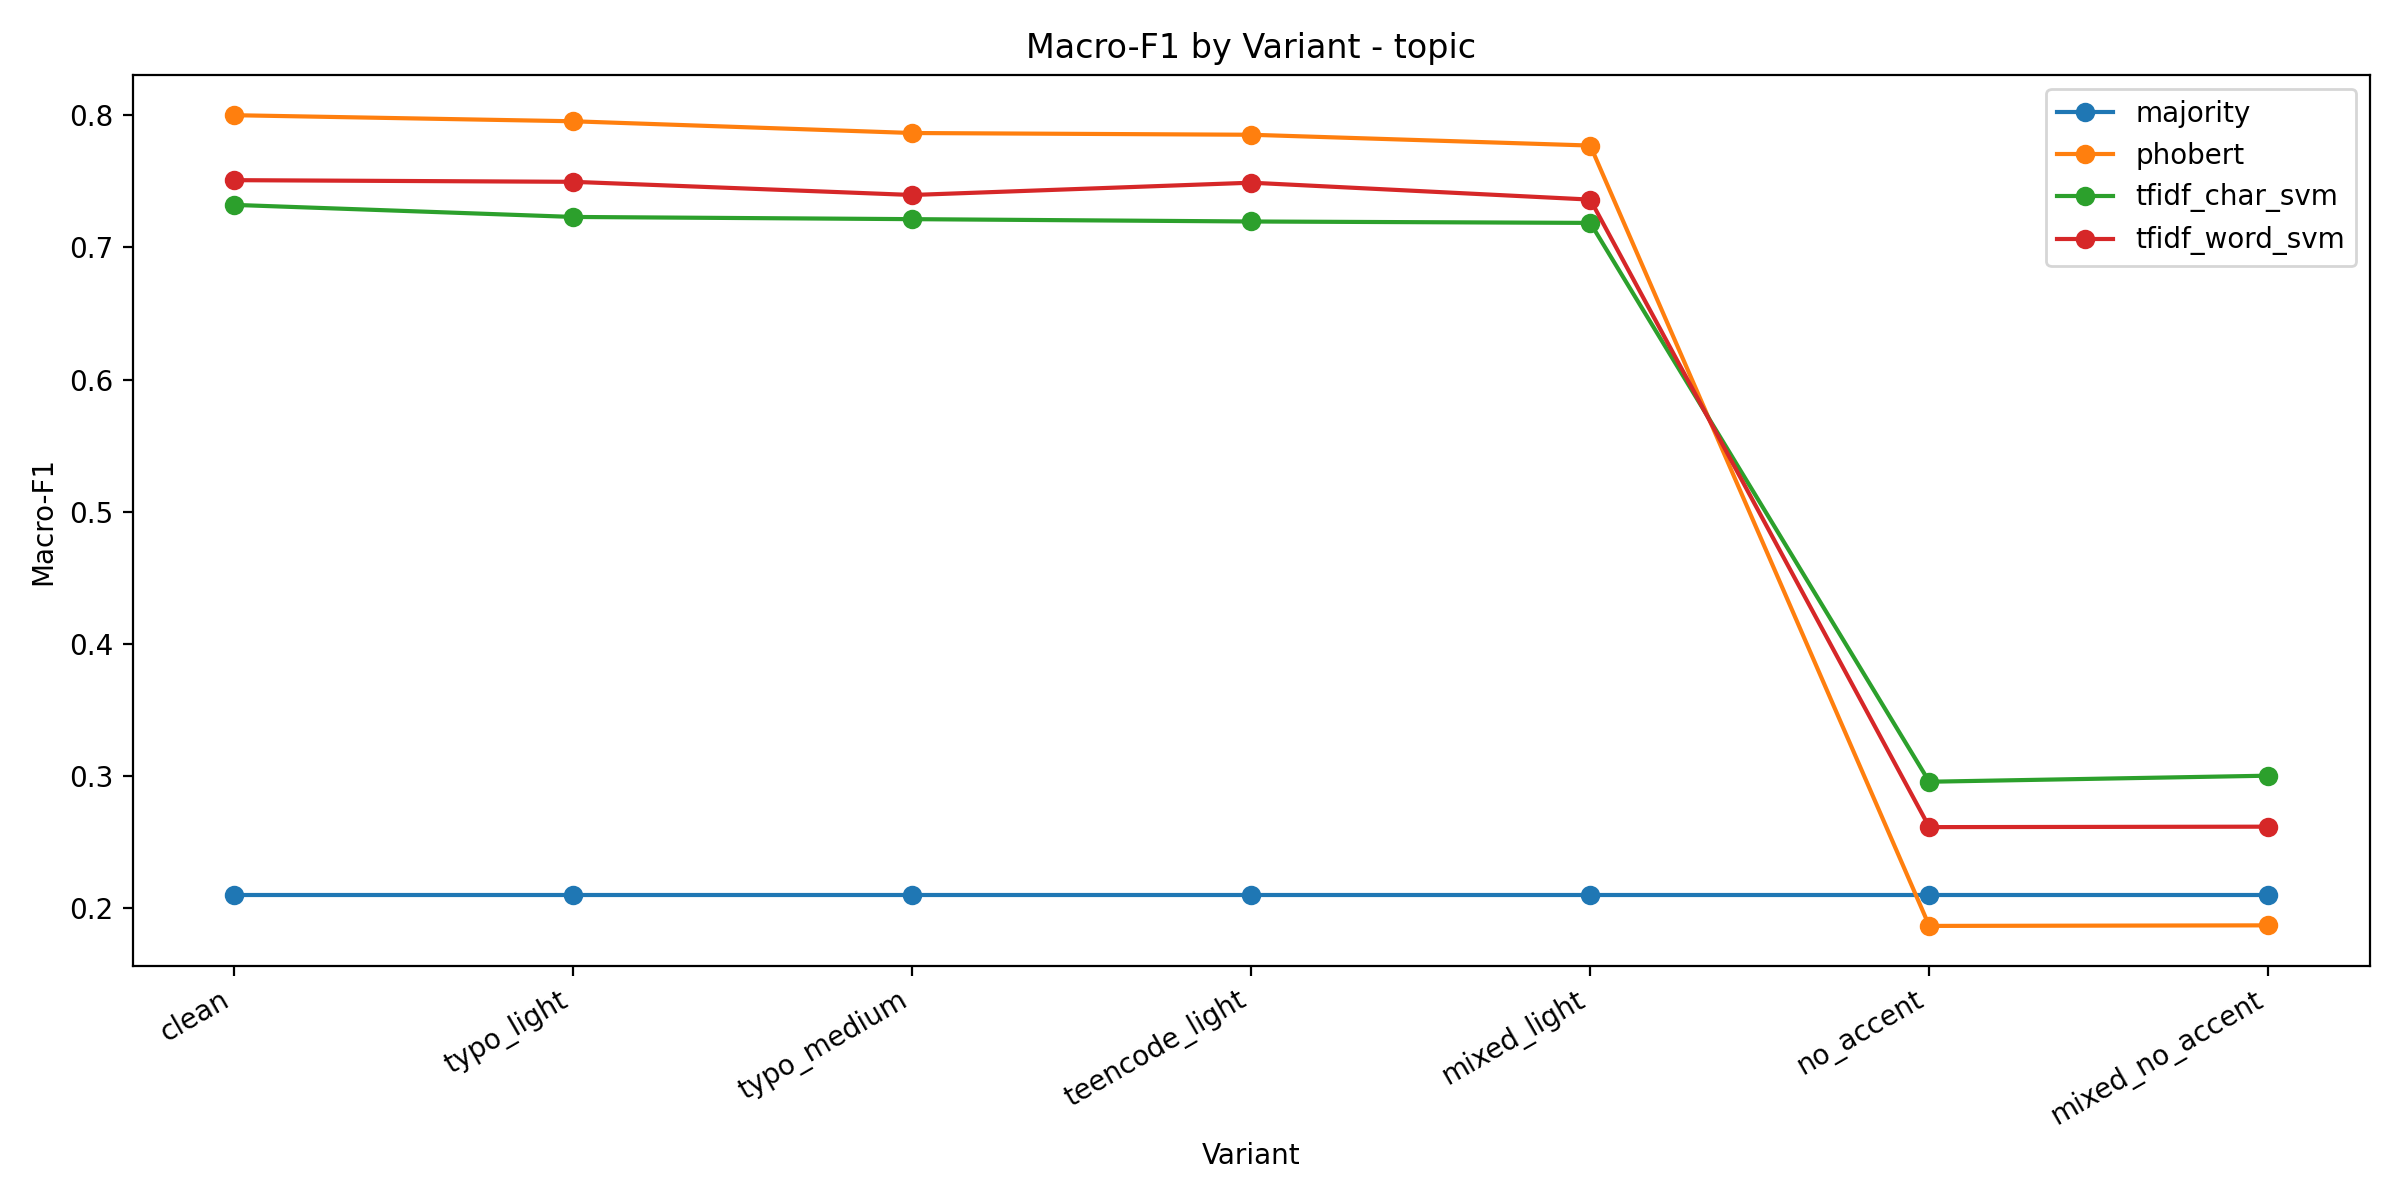

In [9]:
display(Markdown("### Sentiment"))
display(Image(filename=str(FIGURES_DIR / "final_robustness_macro_f1_sentiment.png")))

display(Markdown("### Topic"))
display(Image(filename=str(FIGURES_DIR / "final_robustness_macro_f1_topic.png")))

## 8. Macro-F1 drop theo variant

Mục tiêu: trả lời RQ2 — loại noise nào gây suy giảm mạnh nhất.

### Sentiment

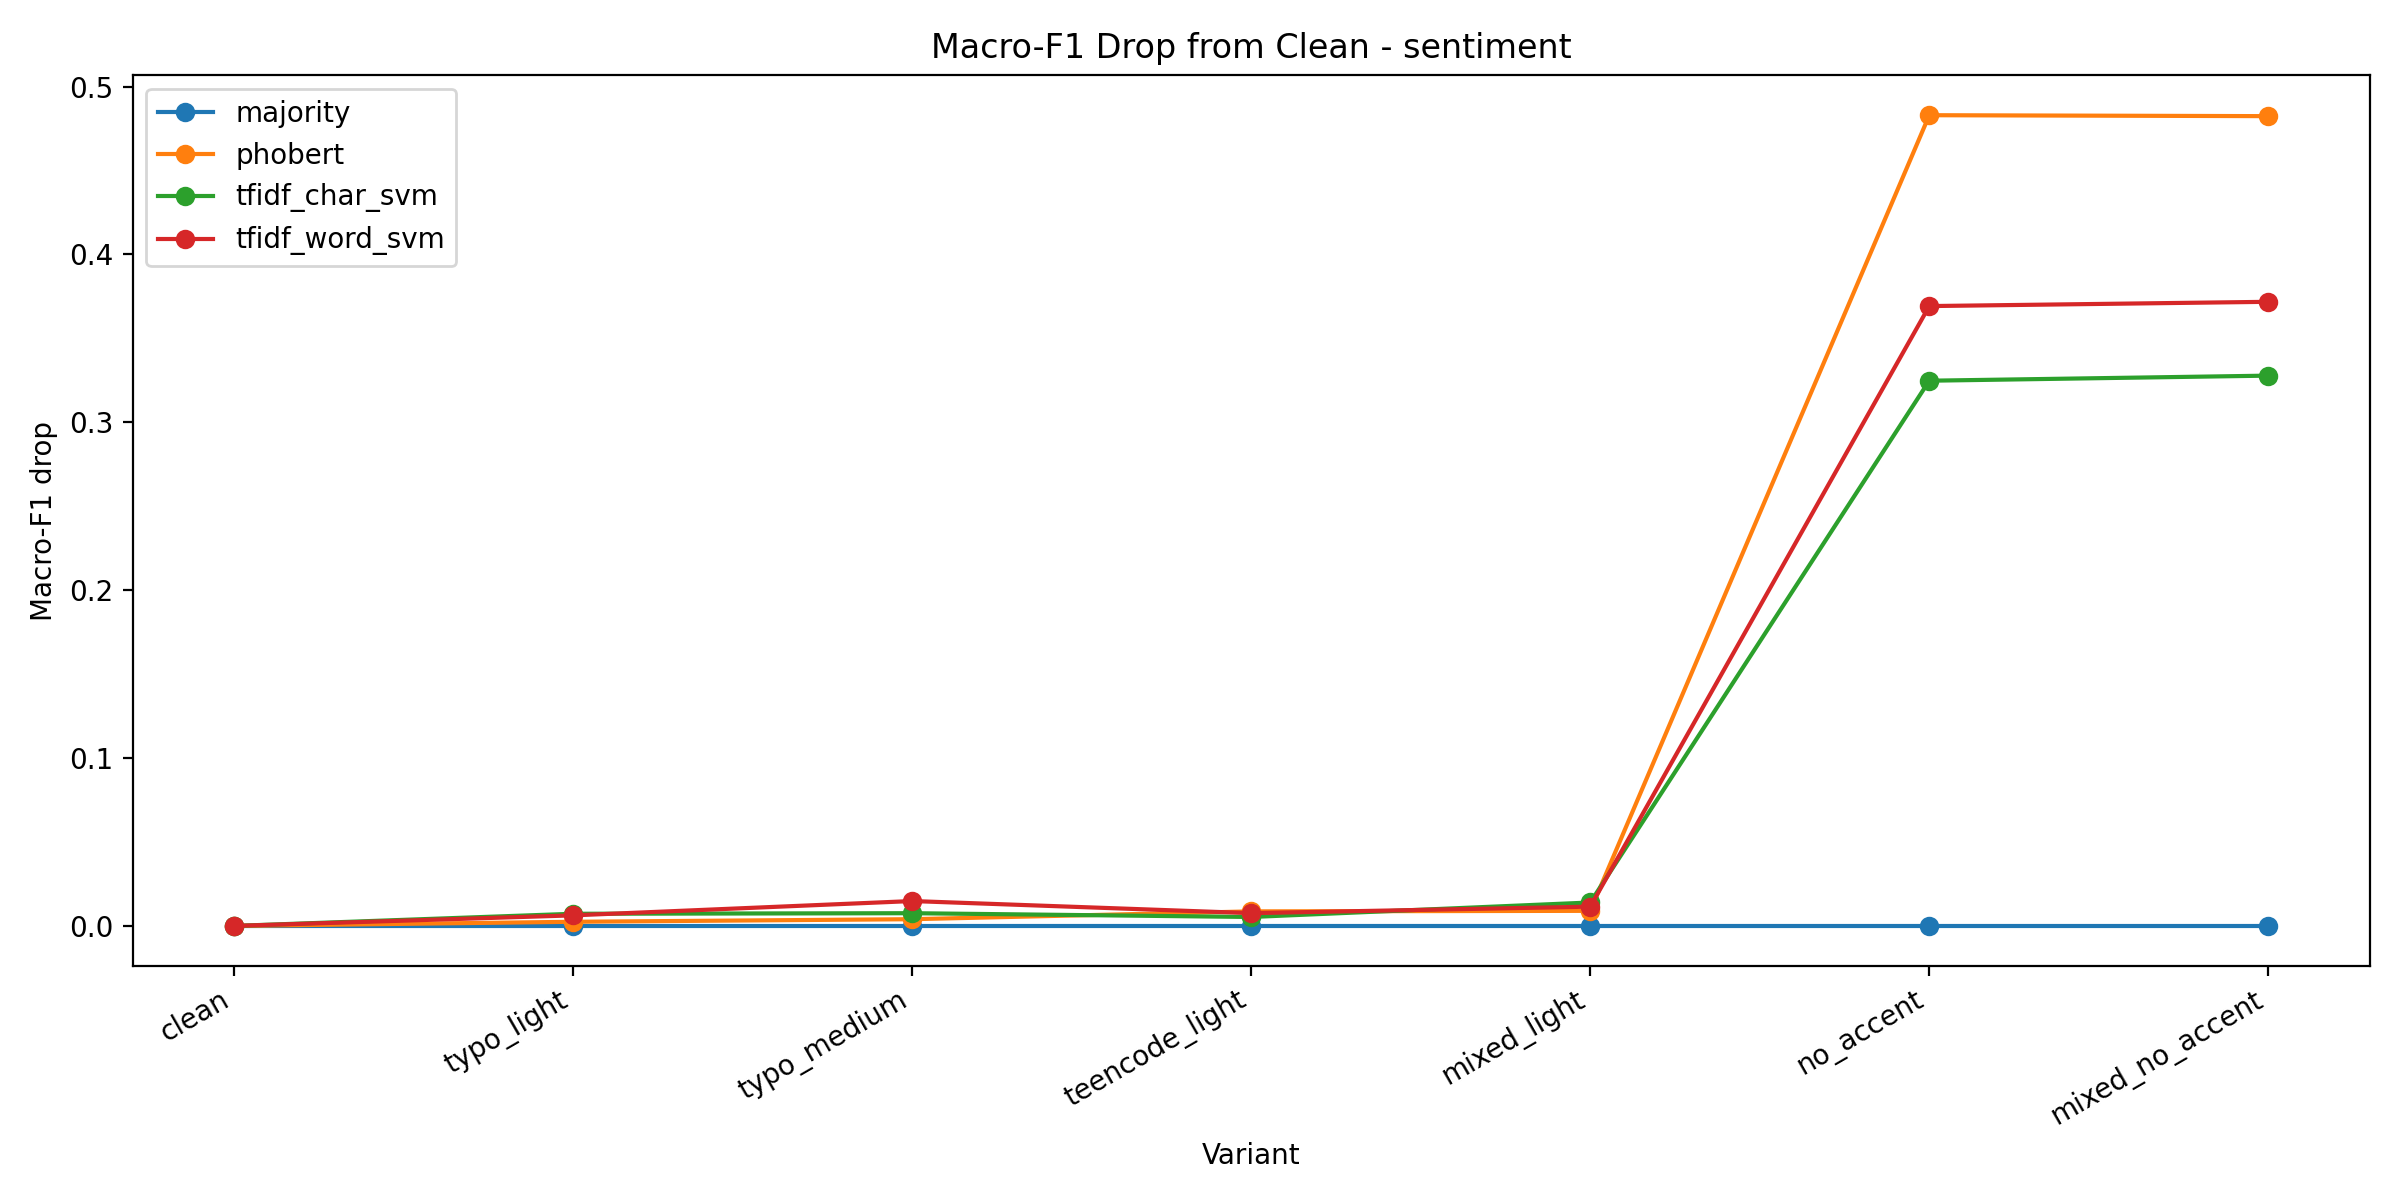

### Topic

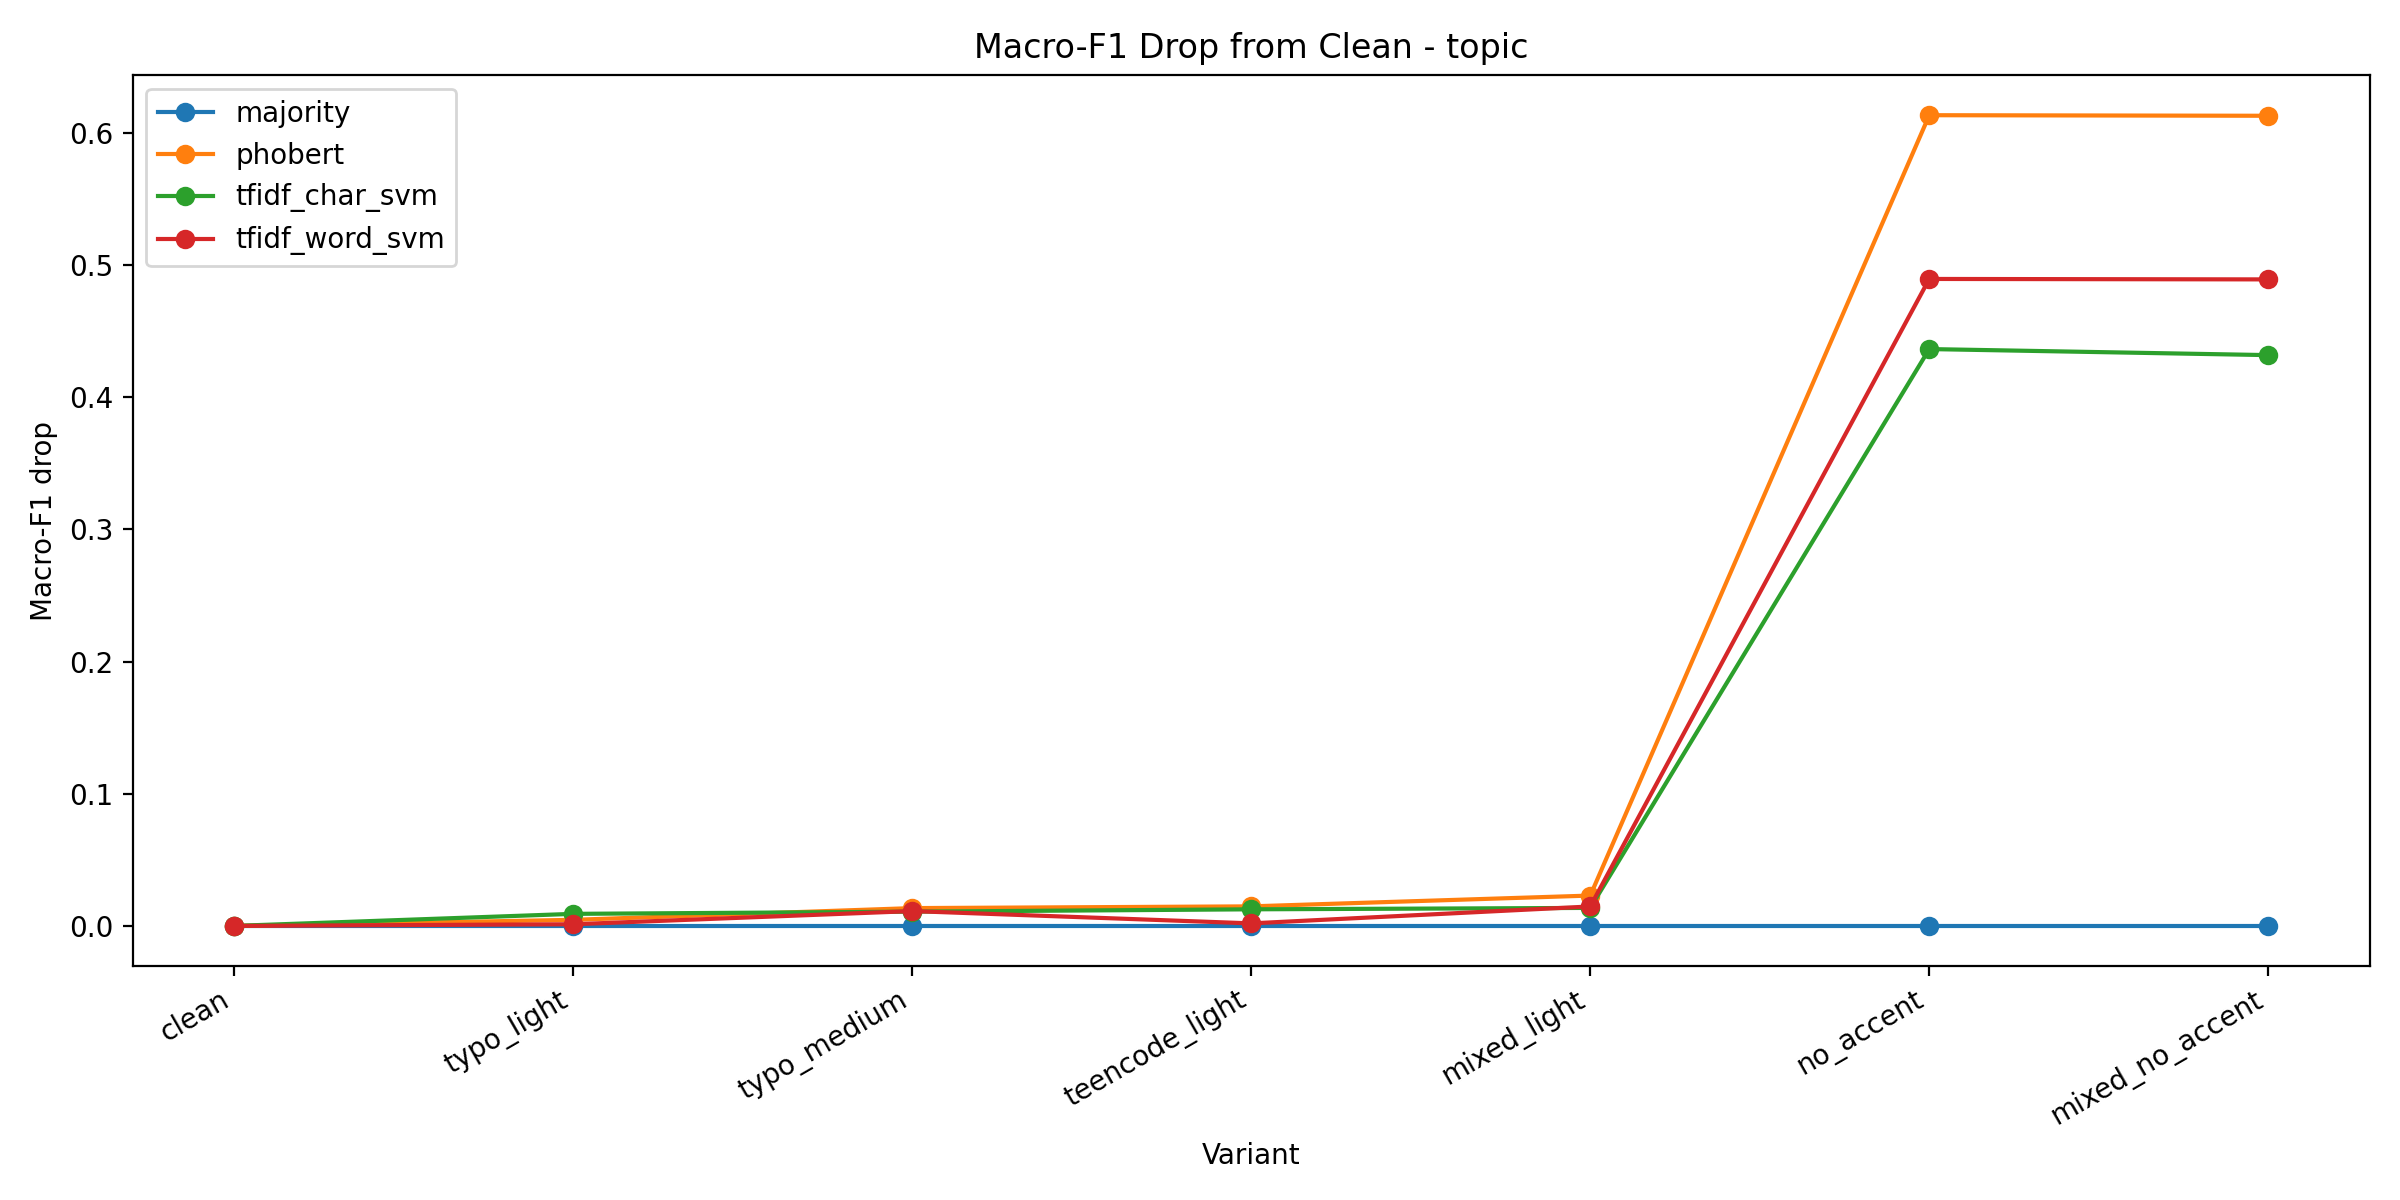

In [10]:
display(Markdown("### Sentiment"))
display(Image(filename=str(FIGURES_DIR / "final_robustness_drop_sentiment.png")))

display(Markdown("### Topic"))
display(Image(filename=str(FIGURES_DIR / "final_robustness_drop_topic.png")))

## 9. Worst drop theo từng model

Mục tiêu: xác định mỗi model yếu nhất ở loại noise nào.

In [11]:
worst_drop = (
    robustness[robustness["variant"] != "clean"]
    .sort_values(["task", "model", "macro_f1_drop"], ascending=[True, True, False])
    .groupby(["task", "model"])
    .head(1)
    .reset_index(drop=True)
)

display(worst_drop[[
    "task",
    "model",
    "variant",
    "clean_macro_f1",
    "variant_macro_f1",
    "macro_f1_drop",
    "macro_f1_relative_drop_percent",
]])

for _, row in worst_drop.iterrows():
    display(Markdown(
        f"- **{row['task']} / {row['model']}**: worst variant = `{row['variant']}`, "
        f"Macro-F1 drop = **{row['macro_f1_drop']:.4f}** "
        f"({row['macro_f1_relative_drop_percent']:.2f}%)."
    ))

,task,model,variant,clean_macro_f1,variant_macro_f1,macro_f1_drop,macro_f1_relative_drop_percent
0,sentiment,majority,typo_light,0.222876,0.222876,0.000000,0.0000
1,sentiment,phobert,no_accent,0.822815,0.339899,0.482916,58.6907
2,sentiment,tfidf_char_svm,mixed_no_accent,0.738784,0.411000,0.327784,44.3680
3,sentiment,tfidf_word_svm,mixed_no_accent,0.728904,0.357145,0.371759,51.0025
4,topic,majority,typo_light,0.209861,0.209861,0.000000,0.0000
5,topic,phobert,no_accent,0.800073,0.186600,0.613473,76.6771
6,topic,tfidf_char_svm,no_accent,0.732207,0.295702,0.436505,59.6150
7,topic,tfidf_word_svm,no_accent,0.750922,0.261359,0.489563,65.1949


- **sentiment / majority**: worst variant = `typo_light`, Macro-F1 drop = **0.0000** (0.00%).

- **sentiment / phobert**: worst variant = `no_accent`, Macro-F1 drop = **0.4829** (58.69%).

- **sentiment / tfidf_char_svm**: worst variant = `mixed_no_accent`, Macro-F1 drop = **0.3278** (44.37%).

- **sentiment / tfidf_word_svm**: worst variant = `mixed_no_accent`, Macro-F1 drop = **0.3718** (51.00%).

- **topic / majority**: worst variant = `typo_light`, Macro-F1 drop = **0.0000** (0.00%).

- **topic / phobert**: worst variant = `no_accent`, Macro-F1 drop = **0.6135** (76.68%).

- **topic / tfidf_char_svm**: worst variant = `no_accent`, Macro-F1 drop = **0.4365** (59.62%).

- **topic / tfidf_word_svm**: worst variant = `no_accent`, Macro-F1 drop = **0.4896** (65.19%).

## 10. PhoBERT vs best baseline trên no_accent

Mục tiêu: kiểm tra kết luận quan trọng nhất của robustness: PhoBERT có thua char-level SVM khi mất dấu không?

In [12]:
focus_variants = ["no_accent", "mixed_no_accent"]

focus = robustness[robustness["variant"].isin(focus_variants)].copy()

display(focus[[
    "task",
    "variant",
    "model",
    "model_family",
    "accuracy",
    "macro_f1",
    "macro_f1_drop",
    "rank_macro_f1_within_variant",
]])

phobert_focus = focus[focus["model"] == "phobert"][
    ["task", "variant", "macro_f1"]
].rename(columns={"macro_f1": "phobert_macro_f1"})

best_baseline_focus = (
    focus[focus["model_family"] == "baseline"]
    .sort_values(["task", "variant", "macro_f1"], ascending=[True, True, False])
    .groupby(["task", "variant"])
    .head(1)
    [["task", "variant", "model", "macro_f1"]]
    .rename(columns={"model": "best_baseline_model", "macro_f1": "best_baseline_macro_f1"})
)

focus_compare = best_baseline_focus.merge(
    phobert_focus,
    on=["task", "variant"],
    how="inner",
)

focus_compare["phobert_minus_best_baseline"] = (
    focus_compare["phobert_macro_f1"] - focus_compare["best_baseline_macro_f1"]
)

display(Markdown("### PhoBERT vs best baseline on no-accent variants"))
display(focus_compare)

for _, row in focus_compare.iterrows():
    direction = "higher" if row["phobert_minus_best_baseline"] > 0 else "lower"
    display(Markdown(
        f"- **{row['task']} / {row['variant']}**: PhoBERT Macro-F1 is **{direction}** than "
        f"`{row['best_baseline_model']}` by **{row['phobert_minus_best_baseline']:.4f}**."
    ))

,task,variant,model,model_family,accuracy,macro_f1,macro_f1_drop,rank_macro_f1_within_variant
20,sentiment,no_accent,tfidf_char_svm,baseline,0.474416,0.414024,0.324760,1
21,sentiment,no_accent,tfidf_word_svm,baseline,0.406822,0.359685,0.369219,2
22,sentiment,no_accent,phobert,phobert,0.375237,0.339899,0.482916,3
23,sentiment,no_accent,majority,baseline,0.502211,0.222876,0.000000,4
24,sentiment,mixed_no_accent,tfidf_char_svm,baseline,0.469678,0.411000,0.327784,1
25,sentiment,mixed_no_accent,tfidf_word_svm,baseline,0.401453,0.357145,0.371759,2
26,sentiment,mixed_no_accent,phobert,phobert,0.371762,0.340462,0.482353,3
27,sentiment,mixed_no_accent,majority,baseline,0.502211,0.222876,0.000000,4
48,topic,no_accent,tfidf_char_svm,baseline,0.436197,0.295702,0.436505,1
49,topic,no_accent,tfidf_word_svm,baseline,0.329754,0.261359,0.489563,2


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8144\3739354218.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["task", "variant"])


### PhoBERT vs best baseline on no-accent variants

,task,variant,best_baseline_model,best_baseline_macro_f1,phobert_macro_f1,phobert_minus_best_baseline
0,sentiment,no_accent,tfidf_char_svm,0.414024,0.339899,-0.074125
1,sentiment,mixed_no_accent,tfidf_char_svm,0.411000,0.340462,-0.070538
2,topic,no_accent,tfidf_char_svm,0.295702,0.186600,-0.109102
3,topic,mixed_no_accent,tfidf_char_svm,0.300282,0.187029,-0.113253


- **sentiment / no_accent**: PhoBERT Macro-F1 is **lower** than `tfidf_char_svm` by **-0.0741**.

- **sentiment / mixed_no_accent**: PhoBERT Macro-F1 is **lower** than `tfidf_char_svm` by **-0.0705**.

- **topic / no_accent**: PhoBERT Macro-F1 is **lower** than `tfidf_char_svm` by **-0.1091**.

- **topic / mixed_no_accent**: PhoBERT Macro-F1 is **lower** than `tfidf_char_svm` by **-0.1133**.

## 11. Per-class comparison

Mục tiêu: phân tích lớp nào yếu và lớp nào bị ảnh hưởng bởi noise.

In [13]:
per_class = final_per_class_comparison.copy()
summary_labels = {"accuracy", "macro avg", "weighted avg"}
per_class_only = per_class[~per_class["label"].isin(summary_labels)].copy()

display(per_class_only.head(30))

for task in per_class_only["task"].dropna().unique():
    display(Markdown(f"### Clean per-class F1 — {task}"))
    clean_pc = per_class_only[
        (per_class_only["task"] == task) &
        (per_class_only["variant"] == "clean")
    ].copy()
    pivot = clean_pc.pivot_table(
        index="label",
        columns="model",
        values="f1_score",
        observed=False,
    )
    display(pivot)

,task,model,variant,label,precision,recall,f1_score,support,model_family,is_summary_label,variant_order,model_order
0,sentiment,majority,clean,negative,0.000000,0.000000,0.000000,1409.0,baseline,False,0,0
1,sentiment,majority,clean,neutral,0.000000,0.000000,0.000000,167.0,baseline,False,0,0
2,sentiment,majority,clean,positive,0.502211,1.000000,0.668629,1590.0,baseline,False,0,0
6,sentiment,tfidf_word_svm,clean,negative,0.882119,0.945351,0.912641,1409.0,baseline,False,0,1
7,sentiment,tfidf_word_svm,clean,neutral,0.445455,0.293413,0.353791,167.0,baseline,False,0,1
8,sentiment,tfidf_word_svm,clean,positive,0.933376,0.907547,0.920281,1590.0,baseline,False,0,1
12,sentiment,tfidf_char_svm,clean,negative,0.880248,0.907736,0.893781,1409.0,baseline,False,0,2
13,sentiment,tfidf_char_svm,clean,neutral,0.395604,0.431138,0.412607,167.0,baseline,False,0,2
14,sentiment,tfidf_char_svm,clean,positive,0.927498,0.893082,0.909965,1590.0,baseline,False,0,2
18,sentiment,phobert,clean,negative,0.943357,0.957417,0.950335,1409.0,phobert,False,0,3


### Clean per-class F1 — sentiment

model,majority,phobert,tfidf_char_svm,tfidf_word_svm
label,,,,
negative,0.000000,0.950335,0.893781,0.912641
neutral,0.000000,0.568627,0.412607,0.353791
positive,0.668629,0.949482,0.909965,0.920281


### Clean per-class F1 — topic

model,majority,phobert,tfidf_char_svm,tfidf_word_svm
label,,,,
facility,0.000000,0.924138,0.886667,0.914676
lecturer,0.839443,0.943552,0.905235,0.920452
others,0.000000,0.546763,0.461538,0.451827
training_program,0.000000,0.785838,0.675388,0.716735


## 12. Per-class F1 drop: clean → no_accent

Mục tiêu: xem lớp nào của PhoBERT sụp mạnh nhất khi bỏ dấu.

In [14]:
phobert_pc = per_class_only[per_class_only["model"] == "phobert"].copy()

clean_pc = phobert_pc[phobert_pc["variant"] == "clean"][
    ["task", "label", "precision", "recall", "f1_score"]
].rename(
    columns={
        "precision": "clean_precision",
        "recall": "clean_recall",
        "f1_score": "clean_f1",
    }
)

no_accent_pc = phobert_pc[phobert_pc["variant"] == "no_accent"][
    ["task", "label", "precision", "recall", "f1_score"]
].rename(
    columns={
        "precision": "no_accent_precision",
        "recall": "no_accent_recall",
        "f1_score": "no_accent_f1",
    }
)

pc_drop = clean_pc.merge(no_accent_pc, on=["task", "label"], how="inner")
pc_drop["f1_drop"] = pc_drop["clean_f1"] - pc_drop["no_accent_f1"]
pc_drop["relative_f1_drop_percent"] = pc_drop.apply(
    lambda row: 0.0 if row["clean_f1"] == 0 else round(row["f1_drop"] / row["clean_f1"] * 100, 4),
    axis=1,
)

pc_drop = pc_drop.sort_values(["task", "f1_drop"], ascending=[True, False])

display(pc_drop)

for task, group_df in pc_drop.groupby("task"):
    worst = group_df.iloc[0]
    display(Markdown(
        f"- **{task}**: largest PhoBERT F1 drop under `no_accent` is `{worst['label']}` "
        f"with drop = **{worst['f1_drop']:.4f}**."
    ))

,task,label,clean_precision,clean_recall,clean_f1,no_accent_precision,no_accent_recall,no_accent_f1,f1_drop,relative_f1_drop_percent
0,sentiment,negative,0.943357,0.957417,0.950335,0.555147,0.214336,0.309268,0.641067,67.4570
1,sentiment,neutral,0.625899,0.520958,0.568627,0.080186,0.724551,0.144391,0.424236,74.6070
2,sentiment,positive,0.947401,0.951572,0.949482,0.687332,0.481132,0.566038,0.383445,40.3846
3,topic,facility,0.924138,0.924138,0.924138,0.288889,0.089655,0.136842,0.787296,85.1925
6,topic,training_program,0.776451,0.795455,0.785838,0.107143,0.068182,0.083333,0.702504,89.3956
4,topic,lecturer,0.938256,0.948908,0.943552,0.821333,0.268996,0.405263,0.538289,57.0492
5,topic,others,0.638655,0.477987,0.546763,0.065272,0.823899,0.120960,0.425802,77.8770


- **sentiment**: largest PhoBERT F1 drop under `no_accent` is `negative` with drop = **0.6411**.

- **topic**: largest PhoBERT F1 drop under `no_accent` is `facility` with drop = **0.7873**.

## 13. Error transition summary — Sentiment

Mục tiêu: trả lời RQ4 — mô hình nhầm từ lớp nào sang lớp nào?

In [15]:
transition_sentiment_view = transition_sentiment.copy()
display(transition_sentiment_view.head(30))

for variant in transition_sentiment_view["variant"].dropna().unique():
    display(Markdown(f"### Sentiment transitions — {variant}"))
    display(
        transition_sentiment_view[transition_sentiment_view["variant"] == variant]
        .sort_values("count", ascending=False)
        .head(10)
    )

,task,variant,y_true_name,y_pred_name,count,total_wrong_in_variant,percent_within_wrong
0,sentiment,mixed_light,positive,negative,57,248,22.9839
1,sentiment,mixed_light,negative,positive,53,248,21.3710
2,sentiment,mixed_light,neutral,positive,52,248,20.9677
3,sentiment,mixed_light,negative,neutral,31,248,12.5000
4,sentiment,mixed_light,positive,neutral,28,248,11.2903
5,sentiment,mixed_light,neutral,negative,27,248,10.8871
6,sentiment,mixed_no_accent,negative,neutral,797,1989,40.0704
7,sentiment,mixed_no_accent,positive,neutral,620,1989,31.1714
8,sentiment,mixed_no_accent,negative,positive,291,1989,14.6305
9,sentiment,mixed_no_accent,positive,negative,235,1989,11.8150


### Sentiment transitions — mixed_light

,task,variant,y_true_name,y_pred_name,count,total_wrong_in_variant,percent_within_wrong
0,sentiment,mixed_light,positive,negative,57,248,22.9839
1,sentiment,mixed_light,negative,positive,53,248,21.3710
2,sentiment,mixed_light,neutral,positive,52,248,20.9677
3,sentiment,mixed_light,negative,neutral,31,248,12.5000
4,sentiment,mixed_light,positive,neutral,28,248,11.2903
5,sentiment,mixed_light,neutral,negative,27,248,10.8871


### Sentiment transitions — mixed_no_accent

,task,variant,y_true_name,y_pred_name,count,total_wrong_in_variant,percent_within_wrong
6,sentiment,mixed_no_accent,negative,neutral,797,1989,40.0704
7,sentiment,mixed_no_accent,positive,neutral,620,1989,31.1714
8,sentiment,mixed_no_accent,negative,positive,291,1989,14.6305
9,sentiment,mixed_no_accent,positive,negative,235,1989,11.8150
10,sentiment,mixed_no_accent,neutral,positive,34,1989,1.7094
11,sentiment,mixed_no_accent,neutral,negative,12,1989,0.6033


### Sentiment transitions — no_accent

,task,variant,y_true_name,y_pred_name,count,total_wrong_in_variant,percent_within_wrong
12,sentiment,no_accent,negative,neutral,792,1978,40.0404
13,sentiment,no_accent,positive,neutral,596,1978,30.1314
14,sentiment,no_accent,negative,positive,315,1978,15.9252
15,sentiment,no_accent,positive,negative,229,1978,11.5774
16,sentiment,no_accent,neutral,positive,33,1978,1.6684
17,sentiment,no_accent,neutral,negative,13,1978,0.6572


## 14. Error transition summary — Topic

In [16]:
transition_topic_view = transition_topic.copy()
display(transition_topic_view.head(30))

for variant in transition_topic_view["variant"].dropna().unique():
    display(Markdown(f"### Topic transitions — {variant}"))
    display(
        transition_topic_view[transition_topic_view["variant"] == variant]
        .sort_values("count", ascending=False)
        .head(10)
    )

,task,variant,y_true_name,y_pred_name,count,total_wrong_in_variant,percent_within_wrong
0,topic,mixed_light,training_program,lecturer,109,376,28.9894
1,topic,mixed_light,lecturer,training_program,102,376,27.1277
2,topic,mixed_light,others,lecturer,43,376,11.4362
3,topic,mixed_light,others,training_program,39,376,10.3723
4,topic,mixed_light,lecturer,others,34,376,9.0426
5,topic,mixed_light,training_program,others,22,376,5.8511
6,topic,mixed_light,facility,training_program,6,376,1.5957
7,topic,mixed_light,lecturer,facility,6,376,1.5957
8,topic,mixed_light,facility,lecturer,5,376,1.3298
9,topic,mixed_light,training_program,facility,5,376,1.3298


### Topic transitions — mixed_light

,task,variant,y_true_name,y_pred_name,count,total_wrong_in_variant,percent_within_wrong
0,topic,mixed_light,training_program,lecturer,109,376,28.9894
1,topic,mixed_light,lecturer,training_program,102,376,27.1277
2,topic,mixed_light,others,lecturer,43,376,11.4362
3,topic,mixed_light,others,training_program,39,376,10.3723
4,topic,mixed_light,lecturer,others,34,376,9.0426
5,topic,mixed_light,training_program,others,22,376,5.8511
6,topic,mixed_light,facility,training_program,6,376,1.5957
7,topic,mixed_light,lecturer,facility,6,376,1.5957
8,topic,mixed_light,facility,lecturer,5,376,1.3298
9,topic,mixed_light,training_program,facility,5,376,1.3298


### Topic transitions — mixed_no_accent

,task,variant,y_true_name,y_pred_name,count,total_wrong_in_variant,percent_within_wrong
12,topic,mixed_no_accent,lecturer,others,1355,2393,56.6235
13,topic,mixed_no_accent,training_program,others,440,2393,18.3870
14,topic,mixed_no_accent,lecturer,training_program,320,2393,13.3723
15,topic,mixed_no_accent,facility,others,109,2393,4.5550
16,topic,mixed_no_accent,training_program,lecturer,86,2393,3.5938
17,topic,mixed_no_accent,lecturer,facility,29,2393,1.2119
18,topic,mixed_no_accent,others,lecturer,27,2393,1.1283
19,topic,mixed_no_accent,facility,lecturer,19,2393,0.7940
20,topic,mixed_no_accent,facility,training_program,3,2393,0.1254
21,topic,mixed_no_accent,others,training_program,3,2393,0.1254


### Topic transitions — no_accent

,task,variant,y_true_name,y_pred_name,count,total_wrong_in_variant,percent_within_wrong
23,topic,no_accent,lecturer,others,1325,2367,55.9780
24,topic,no_accent,training_program,others,443,2367,18.7157
25,topic,no_accent,lecturer,training_program,319,2367,13.4770
26,topic,no_accent,facility,others,108,2367,4.5627
27,topic,no_accent,training_program,lecturer,88,2367,3.7178
28,topic,no_accent,lecturer,facility,30,2367,1.2674
29,topic,no_accent,others,lecturer,25,2367,1.0562
30,topic,no_accent,facility,lecturer,21,2367,0.8872
31,topic,no_accent,facility,training_program,3,2367,0.1267
32,topic,no_accent,others,training_program,3,2367,0.1267


## 15. Error examples — Sentiment

Bảng này là mẫu định tính: **clean đúng nhưng noisy sai**.

Lưu ý:

```text
Các ví dụ này dùng để minh họa lỗi.
Không dùng bảng này để tính tỷ lệ lỗi vì mỗi variant chỉ lấy mẫu tối đa 30 dòng.
```

In [17]:
display(error_examples_sentiment.head(30))

for variant in error_examples_sentiment["variant"].dropna().unique():
    display(Markdown(f"### Sentiment error examples — {variant}"))
    cols = [
        "original_text",
        "text",
        "y_true_name",
        "clean_y_pred_name",
        "y_pred_name",
        "error_type",
    ]
    cols = [c for c in cols if c in error_examples_sentiment.columns]
    display(error_examples_sentiment[error_examples_sentiment["variant"] == variant][cols].head(10))

,task,variant,noise_type,noise_level,original_id,original_text,text,y_true,y_true_name,clean_y_pred,clean_y_pred_name,y_pred,y_pred_name,error_type,sentiment_label,sentiment_name,topic_label,topic_name
0,sentiment,no_accent,remove_diacritics,medium,test_2620,"cả 3 , 4 buổi thực hành theo hình thức 2 môn n...","ca 3 , 4 buoi thuc hanh theo hinh thuc 2 mon n...",0,negative,0,negative,1,neutral,clean_correct_noisy_wrong,0,negative,3,others
1,sentiment,no_accent,remove_diacritics,medium,test_2490,dạy không đúng thời gian .,day khong dung thoi gian .,0,negative,0,negative,1,neutral,clean_correct_noisy_wrong,0,negative,0,lecturer
2,sentiment,no_accent,remove_diacritics,medium,test_2582,thầy có kiến thức rất rộng .,thay co kien thuc rat rong .,2,positive,2,positive,0,negative,clean_correct_noisy_wrong,2,positive,0,lecturer
3,sentiment,no_accent,remove_diacritics,medium,test_2974,"sử dụng thời gian lên lớp không hiệu quả , khâ...","su dung thoi gian len lop khong hieu qua , kha...",0,negative,0,negative,1,neutral,clean_correct_noisy_wrong,0,negative,0,lecturer
4,sentiment,no_accent,remove_diacritics,medium,test_1745,cách dạy của thầy cứ như là đọc chữ trong slid...,cach day cua thay cu nhu la doc chu trong slid...,0,negative,0,negative,1,neutral,clean_correct_noisy_wrong,0,negative,0,lecturer
5,sentiment,no_accent,remove_diacritics,medium,test_2086,thầy wzjwz268 không truyền đạt những kiến thức...,thay wzjwz268 khong truyen dat nhung kien thuc...,0,negative,0,negative,1,neutral,clean_correct_noisy_wrong,0,negative,0,lecturer
6,sentiment,no_accent,remove_diacritics,medium,test_986,quá nhiều thứ phải làm trong môn học này .,qua nhieu thu phai lam trong mon hoc nay .,0,negative,0,negative,1,neutral,clean_correct_noisy_wrong,0,negative,1,training_program
7,sentiment,no_accent,remove_diacritics,medium,test_551,khả năng truyền đạt của giảng viên chưa tốt .,kha nang truyen dat cua giang vien chua tot .,0,negative,0,negative,1,neutral,clean_correct_noisy_wrong,0,negative,0,lecturer
8,sentiment,no_accent,remove_diacritics,medium,test_1075,các bài tập thực hành và hoạt động giảng dạy c...,cac bai tap thuc hanh va hoat dong giang day c...,2,positive,2,positive,1,neutral,clean_correct_noisy_wrong,2,positive,1,training_program
9,sentiment,no_accent,remove_diacritics,medium,test_188,cần bài tập có lời giải .,can bai tap co loi giai .,0,negative,0,negative,1,neutral,clean_correct_noisy_wrong,0,negative,1,training_program


### Sentiment error examples — no_accent

,original_text,text,y_true_name,clean_y_pred_name,y_pred_name,error_type
0,"cả 3 , 4 buổi thực hành theo hình thức 2 môn n...","ca 3 , 4 buoi thuc hanh theo hinh thuc 2 mon n...",negative,negative,neutral,clean_correct_noisy_wrong
1,dạy không đúng thời gian .,day khong dung thoi gian .,negative,negative,neutral,clean_correct_noisy_wrong
2,thầy có kiến thức rất rộng .,thay co kien thuc rat rong .,positive,positive,negative,clean_correct_noisy_wrong
3,"sử dụng thời gian lên lớp không hiệu quả , khâ...","su dung thoi gian len lop khong hieu qua , kha...",negative,negative,neutral,clean_correct_noisy_wrong
4,cách dạy của thầy cứ như là đọc chữ trong slid...,cach day cua thay cu nhu la doc chu trong slid...,negative,negative,neutral,clean_correct_noisy_wrong
5,thầy wzjwz268 không truyền đạt những kiến thức...,thay wzjwz268 khong truyen dat nhung kien thuc...,negative,negative,neutral,clean_correct_noisy_wrong
6,quá nhiều thứ phải làm trong môn học này .,qua nhieu thu phai lam trong mon hoc nay .,negative,negative,neutral,clean_correct_noisy_wrong
7,khả năng truyền đạt của giảng viên chưa tốt .,kha nang truyen dat cua giang vien chua tot .,negative,negative,neutral,clean_correct_noisy_wrong
8,các bài tập thực hành và hoạt động giảng dạy c...,cac bai tap thuc hanh va hoat dong giang day c...,positive,positive,neutral,clean_correct_noisy_wrong
9,cần bài tập có lời giải .,can bai tap co loi giai .,negative,negative,neutral,clean_correct_noisy_wrong


### Sentiment error examples — mixed_no_accent

,original_text,text,y_true_name,clean_y_pred_name,y_pred_name,error_type
30,đã vậy còn không tôn trọng sinh viên bằng việc...,da vay con khog ton trong sinh vien bang viec ...,negative,negative,neutral,clean_correct_noisy_wrong
31,kiến thức truyền đạt đến sinh viên rất tốt ạ !,kien thuc truyen dat den snih vien rat tot a !,positive,positive,neutral,clean_correct_noisy_wrong
32,giáo viên dễ tính .,giao vien de tinh .,positive,positive,neutral,clean_correct_noisy_wrong
33,"giáo viên nhiệt tình , giúp đỡ học sinh rèn lu...","giao vien nhiet tnih , giup do hoc sinh ren lu...",positive,positive,neutral,clean_correct_noisy_wrong
34,lớp thực hành không nên học trước lớp lý thuyết .,lop thuc hnh khong nen hoc truoc lop ly thuyet .,negative,negative,neutral,clean_correct_noisy_wrong
35,hơi bắt bẻ .,hoi bat be .,negative,negative,positive,clean_correct_noisy_wrong
36,"giảng viên giảng dạy dễ hiểu , giúp đỡ sinh vi...","giang vien giang day de hieu , giup do sinh vi...",positive,positive,neutral,clean_correct_noisy_wrong
37,"giáo viên không bám sát với sinh viên , không ...","giao vien khong bam sat vs sinh vien , khong n...",negative,negative,neutral,clean_correct_noisy_wrong
38,cô tận tâm và nhiệt tình .,co tan tam va nhiet tinh .,positive,positive,negative,clean_correct_noisy_wrong
39,giảng khó hiểu hơn các thầy cô khác .,giang kho hieu hon cac thay co khac .,negative,negative,neutral,clean_correct_noisy_wrong


### Sentiment error examples — mixed_light

,original_text,text,y_true_name,clean_y_pred_name,y_pred_name,error_type
60,quá nghiêm khắc tạo áp lực .,qua nghiêm khắc tạo áp lực .,negative,negative,positive,clean_correct_noisy_wrong
61,sau lễ 30 fraction 4 - 1 fraction 5 doubledot ...,sau lễ 30 fraction 4 - 1 fraction 5 doubledot ...,negative,negative,neutral,clean_correct_noisy_wrong
62,giáo viên không lên lớp .,giáo viên khong lên lớp .,negative,negative,neutral,clean_correct_noisy_wrong
63,thầy giảng dạy không thu hút cho lắm .,thầy giảng dạy khong thu hút cho lắm .,negative,negative,positive,clean_correct_noisy_wrong
64,giờ lên lớp không chắc chắn .,giờ lên lớp khong chắc chắn .,negative,negative,positive,clean_correct_noisy_wrong
65,dạy chưa hiểu rõ bài .,dạy cưha hiểu rõ bài .,negative,negative,positive,clean_correct_noisy_wrong
66,truyền đạt không dễ hiểu .,truyền đạt kông dễ hiểu .,negative,negative,positive,clean_correct_noisy_wrong
67,"học xong môn này , em không có thêm một chút k...","học xong môn này , em khnôg có thêm một chút k...",negative,negative,neutral,clean_correct_noisy_wrong
68,đừng nghĩ mọi thứ tự em đã biết trước hết colo...,đừg nghĩ mọi thứ tự em đã biết trước hết colon...,negative,negative,neutral,clean_correct_noisy_wrong
69,dành nhiều thời gian trên lớp để chép bài lên ...,dành nhiều tthời gian trên lớp để céhp bài lên...,negative,negative,positive,clean_correct_noisy_wrong


## 16. Error examples — Topic

In [18]:
display(error_examples_topic.head(30))

for variant in error_examples_topic["variant"].dropna().unique():
    display(Markdown(f"### Topic error examples — {variant}"))
    cols = [
        "original_text",
        "text",
        "y_true_name",
        "clean_y_pred_name",
        "y_pred_name",
        "error_type",
    ]
    cols = [c for c in cols if c in error_examples_topic.columns]
    display(error_examples_topic[error_examples_topic["variant"] == variant][cols].head(10))

,task,variant,noise_type,noise_level,original_id,original_text,text,y_true,y_true_name,clean_y_pred,clean_y_pred_name,y_pred,y_pred_name,error_type,sentiment_label,sentiment_name,topic_label,topic_name
0,topic,no_accent,remove_diacritics,medium,test_402,cám ơn thầy fraction cô rất nhiều .,cam on thay fraction co rat nhieu .,0,lecturer,0,lecturer,3,others,clean_correct_noisy_wrong,2,positive,0,lecturer
1,topic,no_accent,remove_diacritics,medium,test_2987,thầy chưa giải đáp thỏa đáng yêu cầu của sinh ...,thay chua giai dap thoa dang yeu cau cua sinh ...,0,lecturer,0,lecturer,1,training_program,clean_correct_noisy_wrong,0,negative,0,lecturer
2,topic,no_accent,remove_diacritics,medium,test_2562,thấy nên lên lớp đầy đủ hon .,thay nen len lop day du hon .,0,lecturer,0,lecturer,1,training_program,clean_correct_noisy_wrong,0,negative,0,lecturer
3,topic,no_accent,remove_diacritics,medium,test_1917,tài liệu của giảng viên đưa ra còn thiếu sót v...,tai lieu cua giang vien dua ra con thieu sot v...,1,training_program,1,training_program,3,others,clean_correct_noisy_wrong,0,negative,1,training_program
4,topic,no_accent,remove_diacritics,medium,test_3011,em fraction tôi nhận thấy phương pháp giảng dạ...,em fraction toi nhan thay phuong phap giang da...,0,lecturer,0,lecturer,3,others,clean_correct_noisy_wrong,0,negative,0,lecturer
5,topic,no_accent,remove_diacritics,medium,test_424,thầy giảng dạy nhiệt tình .,thay giang day nhiet tinh .,0,lecturer,0,lecturer,1,training_program,clean_correct_noisy_wrong,2,positive,0,lecturer
6,topic,no_accent,remove_diacritics,medium,test_2611,thầy giảng bài tập thực hành đa số là thầy ngồ...,thay giang bai tap thuc hanh da so la thay ngo...,0,lecturer,0,lecturer,1,training_program,clean_correct_noisy_wrong,0,negative,0,lecturer
7,topic,no_accent,remove_diacritics,medium,test_2130,thực hành xong ít nhất 3 tuần lý thuyết mới họ...,thuc hanh xong it nhat 3 tuan ly thuyet moi ho...,1,training_program,1,training_program,3,others,clean_correct_noisy_wrong,0,negative,1,training_program
8,topic,no_accent,remove_diacritics,medium,test_107,thầy lý thuyết wzjwz223 cũng thường xuyên đi t...,thay ly thuyet wzjwz223 cung thuong xuyen di t...,0,lecturer,0,lecturer,1,training_program,clean_correct_noisy_wrong,0,negative,0,lecturer
9,topic,no_accent,remove_diacritics,medium,test_412,phần thực hành cần có thời lượng cao hơn và nh...,phan thuc hanh can co thoi luong cao hon va nh...,1,training_program,1,training_program,3,others,clean_correct_noisy_wrong,0,negative,1,training_program


### Topic error examples — no_accent

,original_text,text,y_true_name,clean_y_pred_name,y_pred_name,error_type
0,cám ơn thầy fraction cô rất nhiều .,cam on thay fraction co rat nhieu .,lecturer,lecturer,others,clean_correct_noisy_wrong
1,thầy chưa giải đáp thỏa đáng yêu cầu của sinh ...,thay chua giai dap thoa dang yeu cau cua sinh ...,lecturer,lecturer,training_program,clean_correct_noisy_wrong
2,thấy nên lên lớp đầy đủ hon .,thay nen len lop day du hon .,lecturer,lecturer,training_program,clean_correct_noisy_wrong
3,tài liệu của giảng viên đưa ra còn thiếu sót v...,tai lieu cua giang vien dua ra con thieu sot v...,training_program,training_program,others,clean_correct_noisy_wrong
4,em fraction tôi nhận thấy phương pháp giảng dạ...,em fraction toi nhan thay phuong phap giang da...,lecturer,lecturer,others,clean_correct_noisy_wrong
5,thầy giảng dạy nhiệt tình .,thay giang day nhiet tinh .,lecturer,lecturer,training_program,clean_correct_noisy_wrong
6,thầy giảng bài tập thực hành đa số là thầy ngồ...,thay giang bai tap thuc hanh da so la thay ngo...,lecturer,lecturer,training_program,clean_correct_noisy_wrong
7,thực hành xong ít nhất 3 tuần lý thuyết mới họ...,thuc hanh xong it nhat 3 tuan ly thuyet moi ho...,training_program,training_program,others,clean_correct_noisy_wrong
8,thầy lý thuyết wzjwz223 cũng thường xuyên đi t...,thay ly thuyet wzjwz223 cung thuong xuyen di t...,lecturer,lecturer,training_program,clean_correct_noisy_wrong
9,phần thực hành cần có thời lượng cao hơn và nh...,phan thuc hanh can co thoi luong cao hon va nh...,training_program,training_program,others,clean_correct_noisy_wrong


### Topic error examples — mixed_no_accent

,original_text,text,y_true_name,clean_y_pred_name,y_pred_name,error_type
30,giảng viên không đảm bảo giờ lên lớp và không ...,giang vien khong dam bao gio len lop va khong ...,lecturer,lecturer,others,clean_correct_noisy_wrong
31,"khả năng truyền đạt tốt , dễ hiểu , nhiệt huyế...","kha nang truyen dat tot , de hieu , nhiet huye...",lecturer,lecturer,others,clean_correct_noisy_wrong
32,"cập nhật chương trình học , cần có bộ slide ha...","cap nhat chuong trinh hoc , can co bo slide ha...",training_program,training_program,lecturer,clean_correct_noisy_wrong
33,ít bài tập trên moodle .,it bai tap tren moodle .,training_program,training_program,others,clean_correct_noisy_wrong
34,cộng thêm lớp lý thuyết và thực hành đồng bộ h...,cong them lop ly thuyet va thuc hanh dong bo h...,training_program,training_program,others,clean_correct_noisy_wrong
35,"phòng thực hành nóng , khó chịu , hệ thống máy...","phong thuc hanh nong , kho ciu , he thong may ...",facility,facility,others,clean_correct_noisy_wrong
36,gần gũi .,gan gui .,lecturer,lecturer,others,clean_correct_noisy_wrong
37,"môn cơ chế mã độc là môn rất hay , rất cần thi...","mon co che ma doc la mon rat hay , rat can thi...",training_program,training_program,others,clean_correct_noisy_wrong
38,tâm lý học sinh !,tam ly hoc sinh !,lecturer,lecturer,others,clean_correct_noisy_wrong
39,"các slide khó hiểu , ngôn ngữ trong slide phức...","cac slide kho hieu , ngon ngu trong slde phuc ...",lecturer,lecturer,others,clean_correct_noisy_wrong


### Topic error examples — mixed_light

,original_text,text,y_true_name,clean_y_pred_name,y_pred_name,error_type
60,sinh viên không tiếp thu kịp cũng như không hi...,sinh viên khôông tiếp thu kịp cũng như không h...,training_program,training_program,others,clean_correct_noisy_wrong
61,nên nâng cao cơ sở vật chất của trường .,nên nâng cao csvc của trường .,facility,facility,training_program,clean_correct_noisy_wrong
62,bài tập nhiều và khó .,bt nhiều và khó .,training_program,training_program,lecturer,clean_correct_noisy_wrong
63,giảng viên nên đảm bảo giờ trên lớp và sử dụng...,gv nên đảm bảo giờ trên lớp và sử dụng hiệu qu...,lecturer,lecturer,training_program,clean_correct_noisy_wrong
64,cơ sở vật chất ảnh hưởng đến chất lượng môn học .,csvc ảnh hưởng đến chất lượng môn học .,facility,facility,others,clean_correct_noisy_wrong
65,môn giải tích là một môn khô khan nhưng cô wzj...,môn giải tích là một môn khô khan nhưng cô wzj...,lecturer,lecturer,training_program,clean_correct_noisy_wrong
66,cách chấm điểm giữa các nhóm chưa được công bằ...,cách cấm điểm giữa các nhóm chưa duc cônng bằng .,lecturer,lecturer,training_program,clean_correct_noisy_wrong
67,thêm giờ sửa bài tập các chương sau .,têhm giờ sửa bt các chương sau .,training_program,training_program,lecturer,clean_correct_noisy_wrong
68,odoo quá khó .,odoo qua khó .,training_program,training_program,others,clean_correct_noisy_wrong
69,có kết hợp với bài tập ví dụ .,có kết hợp với bt ví dụ .,training_program,training_program,others,clean_correct_noisy_wrong


## 17. Kết luận trả lời câu hỏi nghiên cứu

### RQ1 — PhoBERT có vượt baseline trên clean test không?

```text
Có. PhoBERT đạt Macro-F1 cao nhất trên clean test ở cả sentiment và topic.
```

### RQ2 — Loại noise nào gây suy giảm mạnh nhất?

```text
no_accent và mixed_no_accent là hai loại noise gây suy giảm mạnh nhất.
```

### RQ3 — PhoBERT có bền hơn baseline không?

```text
Cần chia theo điều kiện:
- Với clean và noise nhẹ, PhoBERT tốt nhất.
- Với no_accent và mixed_no_accent, TF-IDF char SVM bền hơn PhoBERT.
```

### RQ4 — Lớp nào và hướng nhầm nào nổi bật?

```text
Sentiment:
- Nhiều mẫu negative/positive bị kéo sang neutral khi mất dấu.

Topic:
- Nhiều mẫu lecturer/training_program bị kéo sang others khi mất dấu.
```

Diễn giải an toàn:

```text
Clean test đánh giá hiệu năng in-distribution.
Noisy test đánh giá robustness dưới nhiễu có kiểm soát.
Noisy test không được dùng để train hoặc chọn mô hình.
```

## 18. Kết luận Stage 7

Stage 7 hoàn thành khi có đủ:

```text
outputs/tables/final_model_comparison.csv
outputs/tables/final_robustness_comparison.csv
outputs/tables/final_per_class_comparison.csv
outputs/tables/error_examples_sentiment.csv
outputs/tables/error_examples_topic.csv
outputs/tables/error_transition_summary_sentiment.csv
outputs/tables/error_transition_summary_topic.csv
outputs/figures/final_clean_macro_f1_comparison.png
outputs/figures/final_robustness_macro_f1_sentiment.png
outputs/figures/final_robustness_macro_f1_topic.png
outputs/figures/final_robustness_drop_sentiment.png
outputs/figures/final_robustness_drop_topic.png
outputs/reports/final_comparison_report.md
```

Sau Stage 7, dự án đã có đủ kết quả để viết báo cáo chính.

Giai đoạn tiếp theo có hai lựa chọn:

```text
Option A:
Làm Stage 8 — Text Normalization / Robustness Improvement nếu còn thời gian.

Option B:
Bỏ Stage 8 khỏi thực nghiệm chính, đưa vào hướng phát triển và chuyển sang viết báo cáo.
```